In [1]:
import scanpy as sc
import anndata as ad
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42 # ADOBE AI 字帖

from matplotlib.font_manager import fontManager, FontProperties

fontManager.addfont('/data/work/Arial.ttf')

font = FontProperties(fname='/data/work/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name

In [2]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/20250313/xgb/GSE76381/dmt_leiden_20250108_1.pred.h5ad')
adata.obs_names_make_unique()



dic = {
    '0': 'mh_sc_00',
    '9': 'mh_sc_30',
    '1': 'mh_sc_01',
    '4': 'mh_sc_01',
    '12': 'mh_sc_01',
    '2': 'mh_sc_02',
    '26': 'mh_sc_02',
    '3': 'mh_sc_03',
    '5': 'mh_sc_04',
    '6': 'mh_sc_05',
    '19': 'mh_sc_05',
    '7': 'mh_sc_06',
    '8': 'mh_sc_07',
    '10': 'mh_sc_08',
    '11': 'mh_sc_09',
    '31': 'mh_sc_09',
    '13': 'mh_sc_10',
    '14': 'mh_sc_11',
    '15': 'mh_sc_12',
    '16': 'mh_sc_13',
    '17': 'mh_sc_14',
    '18': 'mh_sc_15',
    '35': 'mh_sc_15',
    '20': 'mh_sc_16',
    '21': 'mh_sc_17',
    '22': 'mh_sc_18',
    '23': 'mh_sc_19',
    '24': 'mh_sc_20',
    '25': 'mh_sc_21',
    '27': 'mh_sc_22',
    '32': 'mh_sc_22',
    '28': 'mh_sc_23',
    '29': 'mh_sc_24',
    '30': 'mh_sc_25',
    '33': 'mh_sc_26',
    '34': 'mh_sc_27',
    '36': 'mh_sc_28',
    '38': 'mh_sc_28',
    '37': 'mh_sc_29',
}
adata.obs['dmt_leiden_anno'] = [dic[i] for i in adata.obs['dmt_leiden']]


In [3]:
adatas = []
for i in set(adata.obs['slice_code']):
    temp = adata[adata.obs['slice_code'] == i].copy()
    sc.pp.normalize_total(temp)
    sc.pp.log1p(temp)
    sc.pp.scale(temp, zero_center=False, max_value=10)
    adatas.append(temp)
adata = ad.concat(adatas)


KeyboardInterrupt



In [4]:
adata.X.max()

10.0

In [5]:
names = [
    '20_B03606F3G5_WT202405020032.h5ad',
 '22_B03606C4E6_WT202403310050.h5ad',
 '23_B03609A4D6_WT202404150263.h5ad',
 '27_B03610C1E3_WT202403310051.h5ad',
 '31_B03619A1D3_WT202403310052.h5ad',
 '35_B03619E4G6_WT202403310053.h5ad',
 '39_A03589A1D4_WT202403310046.h5ad',
 '43_A03590E1G4_WT202403310064.h5ad',
 '47_A03593C1F3_WT202403310068.h5ad',
 '51_B03605C2E5_WT202406020126.h5ad',
 '55_B03613E3G6_WT202403310069.h5ad',
 '59_B03612E4G6_WT202403310059.h5ad',
 '63_B03606C1E3_WT202403310061.h5ad',
 '67_A03595A1D3_WT202403310062.h5ad',
 '71_A03595A4D6_WT202403310063.h5ad',
    '75_D03468D1E3_WT202403310066.h5ad',
    '80_D03473D4E6_WT202403310070.h5ad',
    '84_B03423D1E3_WT202403310065.h5ad',
'A03587A5C6_WT2024071215080.h5ad',
'A03988A1C2_WT202407161208.h5ad',
'Y00547PC_WT202407282759.h5ad',
# 'A03591D4E5_WT2024071215074.h5ad',
'A03590A3D6_WT202407192652.h5ad',
'B03618D3F6_WT202407152793.h5ad',
'B03607C4E6_WT2024071214941.h5ad',
'A03994F1G2_WT2024071215067.h5ad',
'A03588A1C2_WT202407161185.h5ad',
]

In [6]:
x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
    x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
    y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
    y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())

In [7]:
fig = plt.figure(figsize=(64, 24))
gs = GridSpec(4, 7, figure=fig)



count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    row = (count // 7) + 1
    col = count % 7  
    ax = fig.add_subplot(gs[row-1, col])

    sc.pl.embedding(
        adata_temp, basis="align_spatial_2d", color='KCNJ6',
        show=False, s=0.5, title='', legend_loc=None, ax=ax, cmap = 'Reds'
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.axis('off')
    ax.set_aspect('equal')
    if count == 0:
        scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
        ax.add_artist(scalebar)
    count += 1
plt.savefig(f'/data/work/mhb/KCNJ6.png', bbox_inches = 'tight', dpi = 600)
plt.close()

In [8]:
temp = adata[adata.obs['dmt_leiden_anno'].isin(['mh_sc_17', 'mh_sc_21'])]

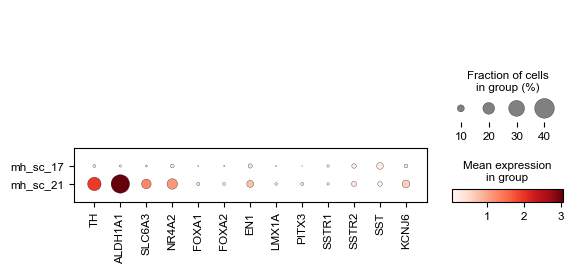

In [9]:
plot = sc.pl.dotplot(temp, 
                     var_names = ['TH','ALDH1A1','SLC6A3','NR4A2','FOXA1','FOXA2','EN1','LMX1A','PITX3', 'SSTR1',
                                    'SSTR2','SST', 'KCNJ6'], groupby = 'dmt_leiden_anno', show=False)
plt.savefig('/data/work/05.cluster/FuseMap/20250313/07_add_marker_dotplot/dotplot_00.pdf', bbox_inches = 'tight')

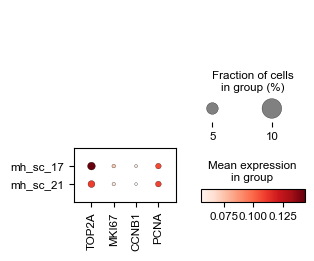

In [ ]:
plot = sc.pl.dotplot(temp, 
                     var_names = ['TOP2A','MKI67','CCNB1','PCNA'], groupby = 'dmt_leiden_anno', show=False)
plt.savefig('/data/work/05.cluster/FuseMap/20250313/07_add_marker_dotplot/dotplot_01.pdf', bbox_inches = 'tight')

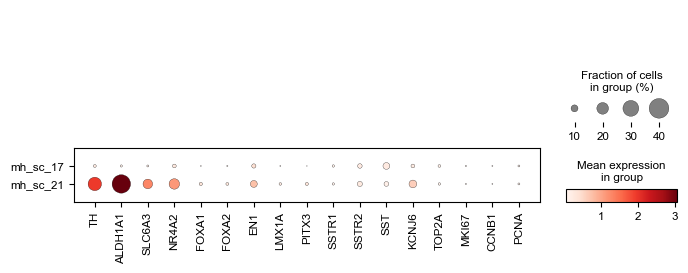

In [ ]:
plot = sc.pl.dotplot(temp, 
                     var_names = ['TH','ALDH1A1','SLC6A3','NR4A2','FOXA1','FOXA2','EN1',
                                  'LMX1A','PITX3', 'SSTR1',
                                    'SSTR2','SST', 'KCNJ6','TOP2A','MKI67','CCNB1','PCNA'], 
                     groupby = 'dmt_leiden_anno', show=False)
plt.savefig('/data/work/05.cluster/FuseMap/20250313/07_add_marker_dotplot/dotplot_02.pdf', 
            bbox_inches = 'tight')